# Beta ablations

No rows for problem=deterministic, T=1500


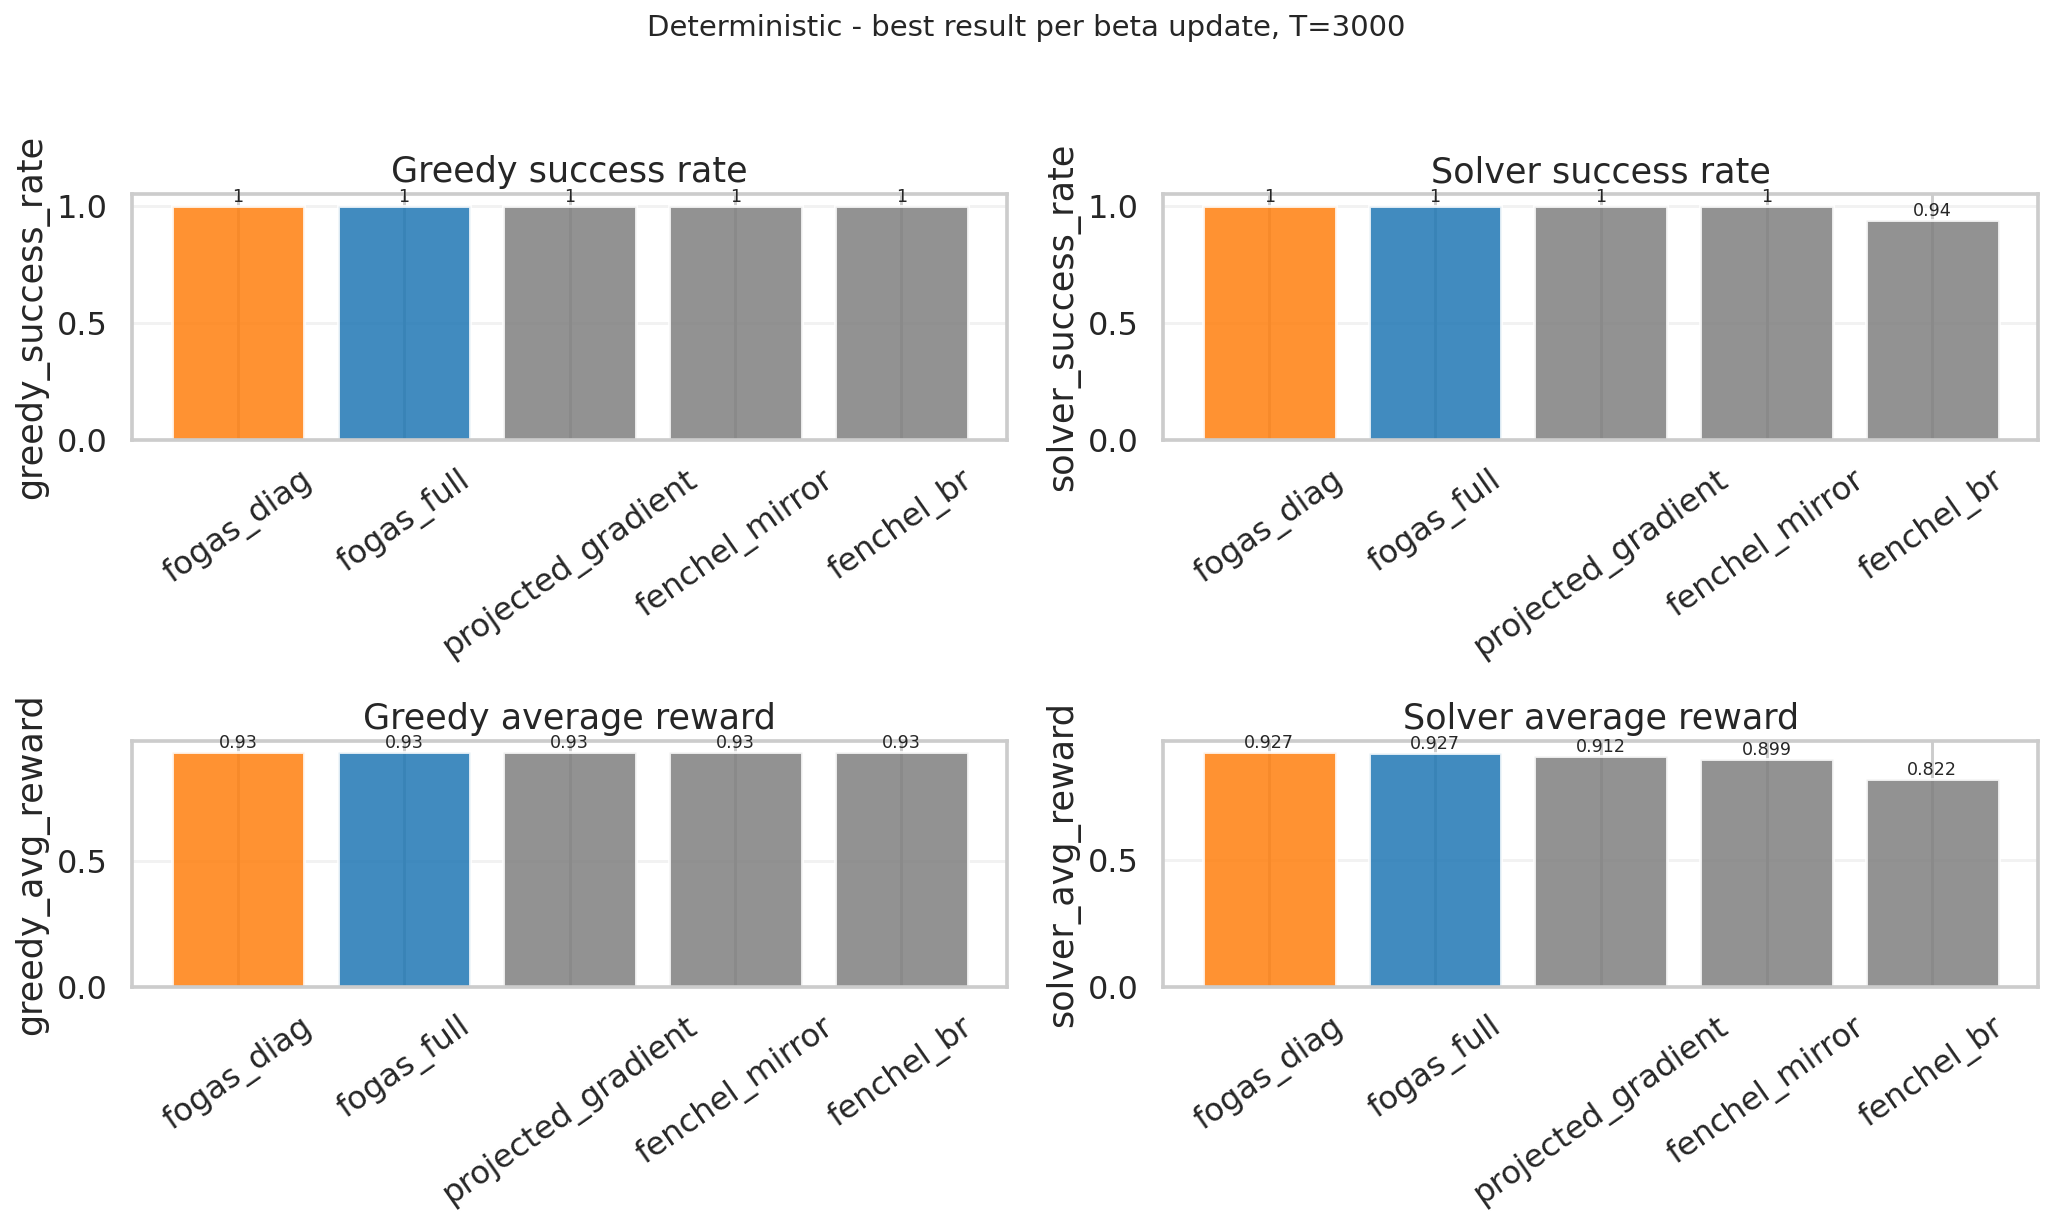

No rows for problem=stochastic, T=1500


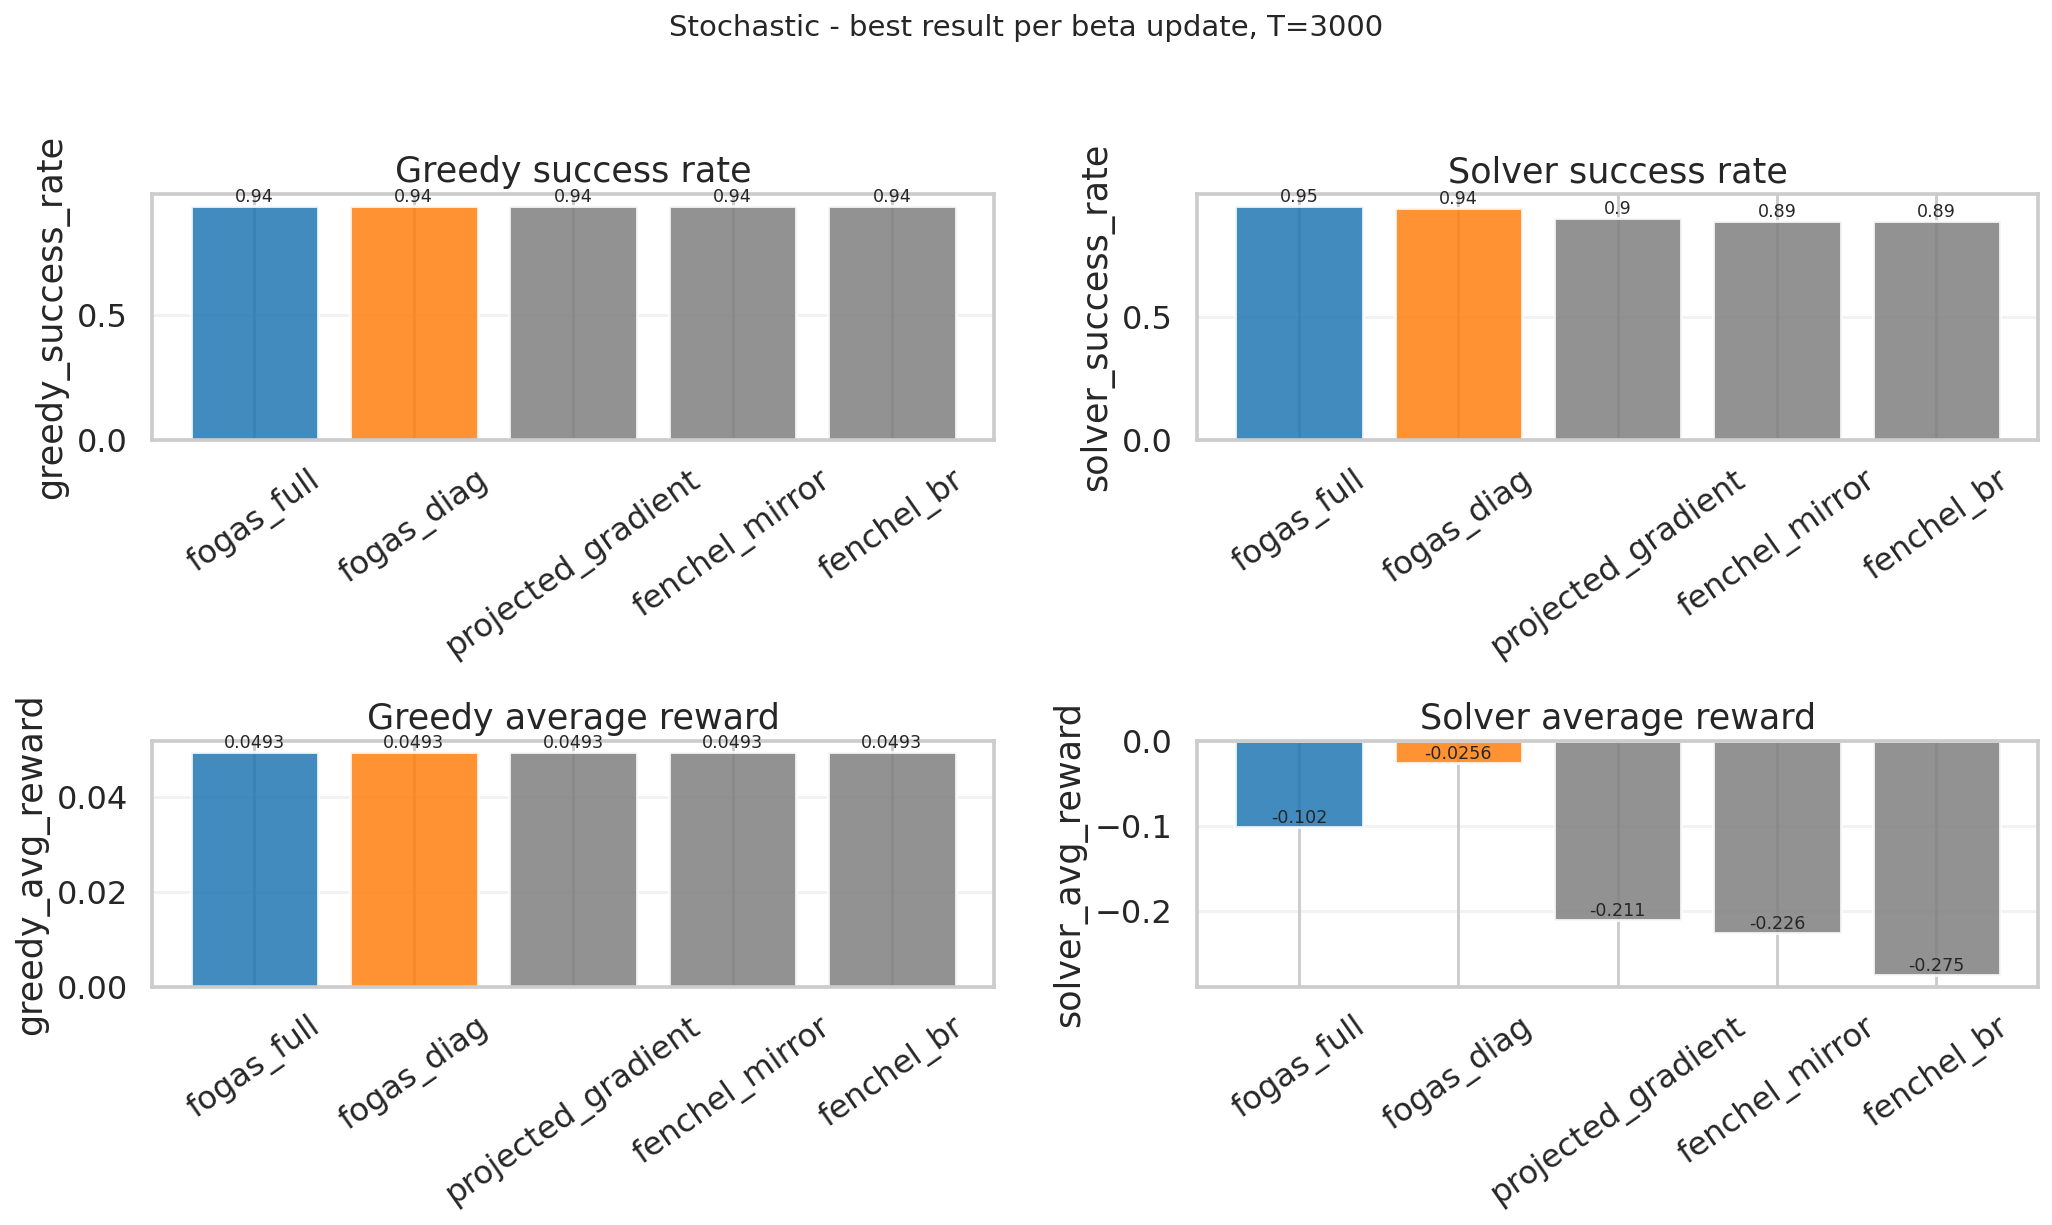

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()


ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"
BETA_CSV = RESULTS_DIR / "final_linear_5grid_tabular_beta_ablation.csv"

METRICS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
]

PROBLEM_ORDER = ["deterministic", "stochastic"]
T_ORDER = [1500, 3000]

UPDATE_ORDER = [
    "fogas_full",
    "fogas_diag",
    "fenchel_mirror",
    "fenchel_br",
    "projected_gradient",
]

RANK_COLUMNS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
    "elapsed_seconds",
]

RANK_ASCENDING = [
    False,
    False,
    False,
    False,
    True,
]

if not BETA_CSV.exists():
    raise FileNotFoundError(f"Missing beta ablation CSV: {BETA_CSV}")

df = pd.read_csv(BETA_CSV)

if "status" in df.columns:
    df = df[df["status"].eq("ok")].copy()

if df.empty:
    raise ValueError("Beta ablation CSV has no successful rows.")

rename = {
    "solver_avg_return": "solver_avg_reward",
    "greedy_avg_return": "greedy_avg_reward",
}
df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

missing = [c for c in ["problem", "beta_update", "T", "eta", "rho", *METRICS] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["run_order"] = df["run_idx"] if "run_idx" in df.columns else np.arange(len(df))

df["problem"] = pd.Categorical(df["problem"], categories=PROBLEM_ORDER, ordered=True)
df["beta_update"] = pd.Categorical(df["beta_update"], categories=UPDATE_ORDER, ordered=True)

rank_cols = [c for c in RANK_COLUMNS if c in df.columns]
rank_ascending = RANK_ASCENDING[: len(rank_cols)]


def best_rows_per_group(data, group_cols):
    return (
        data.sort_values(group_cols + rank_cols, ascending=[True] * len(group_cols) + rank_ascending)
        .groupby(group_cols, as_index=False, observed=True)
        .head(1)
        .reset_index(drop=True)
    )


metric_titles = {
    "greedy_success_rate": "Greedy success rate",
    "solver_success_rate": "Solver success rate",
    "greedy_avg_reward": "Greedy average reward",
    "solver_avg_reward": "Solver average reward",
}


# ============================================================
# 1. Original plots: best row of each beta update
# ============================================================

plot_df = df[df["T"].isin(T_ORDER)].copy()

best_by_problem_t_update = best_rows_per_group(
    plot_df,
    ["problem", "T", "beta_update"],
)

for problem in PROBLEM_ORDER:
    for T in T_ORDER:
        sub = best_by_problem_t_update[
            best_by_problem_t_update["problem"].astype(str).eq(problem)
            & best_by_problem_t_update["T"].eq(T)
        ].copy()

        if sub.empty:
            print(f"No rows for problem={problem}, T={T}")
            continue

        sub = sub.sort_values(rank_cols, ascending=rank_ascending)
        updates = sub["beta_update"].astype(str).tolist()

        fig, axes = plt.subplots(2, 2, figsize=(15, 9))
        axes = axes.ravel()

        for ax, metric in zip(axes, METRICS):
            values = sub[metric].astype(float).values

            colors = [
                "tab:blue" if update == "fogas_full"
                else "tab:orange" if update == "fogas_diag"
                else "tab:gray"
                for update in updates
            ]

            ax.bar(updates, values, color=colors, alpha=0.85)
            ax.set_title(metric_titles.get(metric, metric))
            ax.set_ylabel(metric)
            ax.grid(True, axis="y", alpha=0.25)
            ax.tick_params(axis="x", rotation=35)

            for idx, value in enumerate(values):
                ax.text(idx, value, f"{value:.3g}", ha="center", va="bottom", fontsize=9)

        fig.suptitle(
            f"{problem.capitalize()} - best result per beta update, T={T}",
            fontsize=15,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


# ============================================================
# 2. fogas_full sweep plots: rho and eta
# ============================================================

fogas_full_df = df[df["beta_update"].astype(str).eq("fogas_full")].copy()

if "sweep_family" in fogas_full_df.columns:
    sweep_df = fogas_full_df[fogas_full_df["sweep_family"].astype(str).eq("eta_rho_sweep")].copy()
    if sweep_df.empty:
        sweep_df = fogas_full_df.copy()
else:
    sweep_df = fogas_full_df.copy()


def plot_fogas_full_sweep(data, sweep_param):
    if sweep_param not in data.columns:
        print(f"No column found for sweep parameter: {sweep_param}")
        return

    for problem in PROBLEM_ORDER:
        for T in T_ORDER:
            sub = data[
                data["problem"].astype(str).eq(problem)
                & data["T"].eq(T)
                & data[sweep_param].notna()
            ].copy()

            if sub.empty:
                print(f"No fogas_full rows for problem={problem}, T={T}, sweep={sweep_param}")
                continue

            fixed_param = "eta" if sweep_param == "rho" else "rho"

            if fixed_param in sub.columns:
                best_fixed = best_rows_per_group(sub, [fixed_param]).iloc[0][fixed_param]
                sub = sub[sub[fixed_param].eq(best_fixed)].copy()
                fixed_label = f", fixed {fixed_param}={best_fixed:g}"
            else:
                fixed_label = ""

            sub = (
                sub.sort_values([sweep_param, *rank_cols], ascending=[True] + rank_ascending)
                .groupby(sweep_param, as_index=False, observed=True)
                .head(1)
                .sort_values(sweep_param)
            )

            fig, axes = plt.subplots(2, 2, figsize=(15, 9))
            axes = axes.ravel()

            x = sub[sweep_param].astype(float).values

            for ax, metric in zip(axes, METRICS):
                y = sub[metric].astype(float).values

                ax.plot(x, y, marker="o", linewidth=2, color="tab:blue")
                ax.set_title(metric_titles.get(metric, metric))
                ax.set_xlabel(sweep_param)
                ax.set_ylabel(metric)
                ax.grid(True, alpha=0.25)

                if sweep_param in {"rho", "eta"}:
                    ax.set_xscale("log")

                for xi, yi in zip(x, y):
                    ax.text(xi, yi, f"{yi:.3g}", ha="center", va="bottom", fontsize=9)

            fig.suptitle(
                f"{problem.capitalize()} - fogas_full {sweep_param} sweep, T={T}{fixed_label}",
                fontsize=15,
            )
            fig.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()

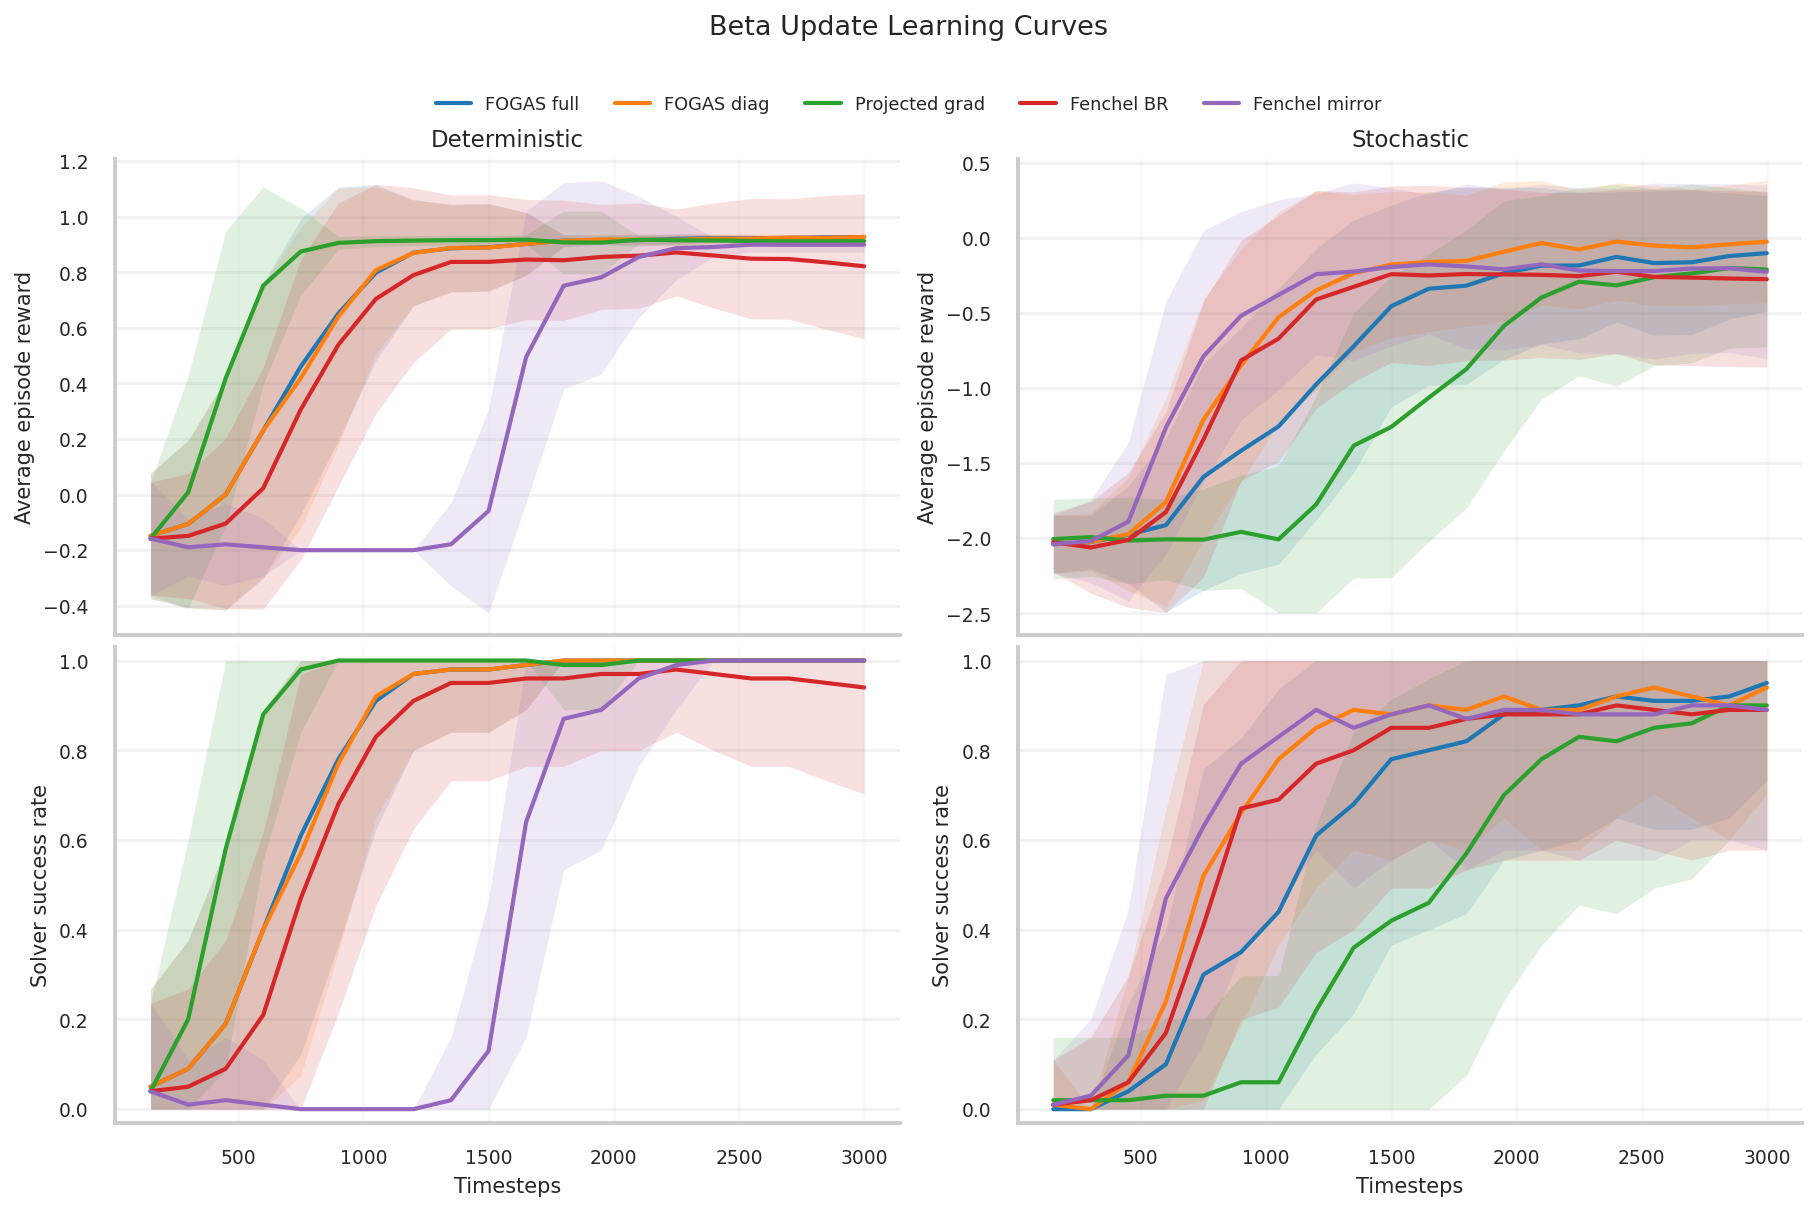

In [46]:
CSV = RESULTS_DIR / "final_linear_5grid_beta_update_learning_curves.csv"

df = pd.read_csv(CSV)
df = df[df["status"].eq("ok")].copy()

df["reward_std"] = df["reward_std"].fillna(0.0)

# This CSV has only one seed, so success-rate std is estimated from Bernoulli rollouts.
df["success_rate_std"] = np.sqrt(
    df["success_rate"].clip(0.0, 1.0) * (1.0 - df["success_rate"].clip(0.0, 1.0))
)

update_order = [
    "fogas_full",
    "fogas_diag",
    "projected_gradient",
    "fenchel_br",
    "fenchel_mirror",
]

labels = {
    "fogas_full": "FOGAS full",
    "fogas_diag": "FOGAS diag",
    "projected_gradient": "Projected grad",
    "fenchel_br": "Fenchel BR",
    "fenchel_mirror": "Fenchel mirror",
}

colors = {
    "fogas_full": "#1f77b4",
    "fogas_diag": "#ff7f0e",
    "projected_gradient": "#2ca02c",
    "fenchel_br": "#d62728",
    "fenchel_mirror": "#9467bd",
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 7.2),
    sharex=True,
    constrained_layout=True,
)

metric_rows = [
    ("avg_reward", "reward_std", "Average episode reward"),
    ("success_rate", "success_rate_std", "Solver success rate"),
]

problems = ["deterministic", "stochastic"]

for col, problem in enumerate(problems):
    sub_problem = df[df["problem"].eq(problem)].copy()

    for row, (metric_col, std_col, ylabel) in enumerate(metric_rows):
        ax = axes[row, col]

        for update in update_order:
            sub = (
                sub_problem[sub_problem["beta_update"].eq(update)]
                .sort_values("step")
            )

            if sub.empty:
                continue

            x = sub["step"].to_numpy(dtype=float)
            y = sub[metric_col].to_numpy(dtype=float)
            err = sub[std_col].fillna(0.0).to_numpy(dtype=float)

            color = colors[update]

            lower = y - err
            upper = y + err

            if metric_col == "success_rate":
                lower = np.clip(lower, 0.0, 1.0)
                upper = np.clip(upper, 0.0, 1.0)

            ax.fill_between(
                x,
                lower,
                upper,
                color=color,
                alpha=0.14,
                linewidth=0,
            )

            ax.plot(
                x,
                y,
                linewidth=2.0,
                color=color,
                label=labels.get(update, update),
            )

        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(True, axis="x", alpha=0.10)
        ax.set_ylabel(ylabel)

        if row == 0:
            ax.set_title(problem.capitalize())

        if row == 1:
            ax.set_xlabel("Timesteps")
            ax.set_ylim(-0.03, 1.03)

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=5,
    frameon=False,
)

fig.suptitle("Beta Update Learning Curves", y=1.10, fontsize=13)
plt.show()

## Rho sweep

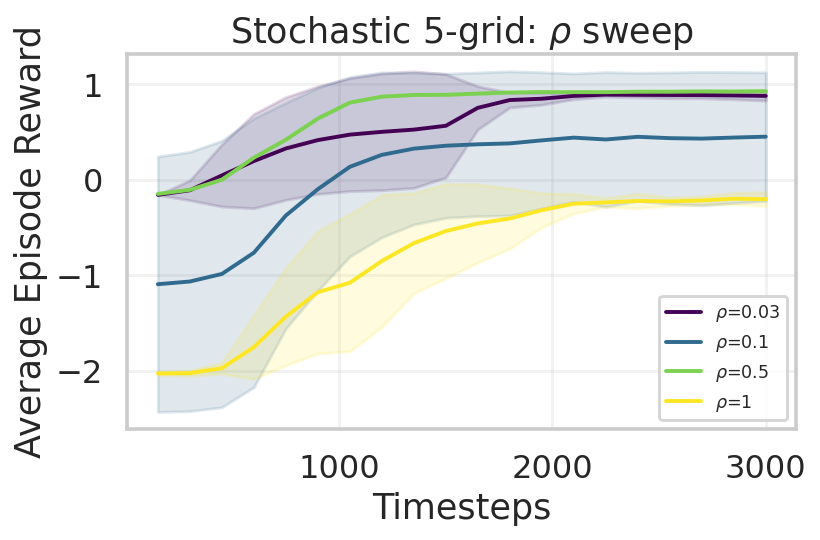

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

plot_df = df.copy()
plot_df.columns = plot_df.columns.str.strip()

if "step" not in plot_df.columns and "checkpoint_step" in plot_df.columns:
    plot_df = plot_df.rename(columns={"checkpoint_step": "step"})

plot_df["rho"] = pd.to_numeric(plot_df["rho"])
plot_df["step"] = pd.to_numeric(plot_df["step"])

if "status" in plot_df.columns:
    plot_df = plot_df[plot_df["status"].eq("ok")]

if "solver_avg_reward_mean" in plot_df.columns:
    mean_col = "solver_avg_reward_mean"
    std_col = "solver_avg_reward_std"
    grouped = plot_df
elif "avg_reward" in plot_df.columns:
    grouped = (
        plot_df.groupby(["rho", "step"], as_index=False)
        .agg(
            reward_mean=("avg_reward", "mean"),
            reward_std=("avg_reward", "std"),
        )
    )
    grouped["reward_std"] = grouped["reward_std"].fillna(0)
    mean_col = "reward_mean"
    std_col = "reward_std"
elif "solver_avg_reward" in plot_df.columns:
    grouped = (
        plot_df.groupby(["rho", "step"], as_index=False)
        .agg(
            reward_mean=("solver_avg_reward", "mean"),
            reward_std=("solver_avg_reward", "std"),
        )
    )
    grouped["reward_std"] = grouped["reward_std"].fillna(0)
    mean_col = "reward_mean"
    std_col = "reward_std"
elif "solver_avg_return" in plot_df.columns:
    grouped = (
        plot_df.groupby(["rho", "step"], as_index=False)
        .agg(
            reward_mean=("solver_avg_return", "mean"),
            reward_std=("solver_avg_return", "std"),
        )
    )
    grouped["reward_std"] = grouped["reward_std"].fillna(0)
    mean_col = "reward_mean"
    std_col = "reward_std"
else:
    raise KeyError(f"No known reward column found. Columns are: {plot_df.columns.tolist()}")

rho_order = sorted(grouped["rho"].dropna().unique())
norm = mcolors.LogNorm(vmin=min(rho_order), vmax=max(rho_order))
cmap = cm.viridis

plt.figure(figsize=(6.2, 4.2))

for rho in rho_order:
    sub = grouped[grouped["rho"].eq(rho)].sort_values("step")

    x = sub["step"].to_numpy()
    y = sub[mean_col].to_numpy()
    err = sub[std_col].fillna(0).to_numpy()

    color = cmap(norm(rho))
    plt.plot(x, y, linewidth=2, color=color, label=fr"$\rho$={rho:g}")
    plt.fill_between(x, y - err, y + err, color=color, alpha=0.15)

plt.xlabel("Timesteps")
plt.ylabel("Average Episode Reward")
plt.title(r"Stochastic 5-grid: $\rho$ sweep")
plt.grid(True, alpha=0.25)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

# Policy update

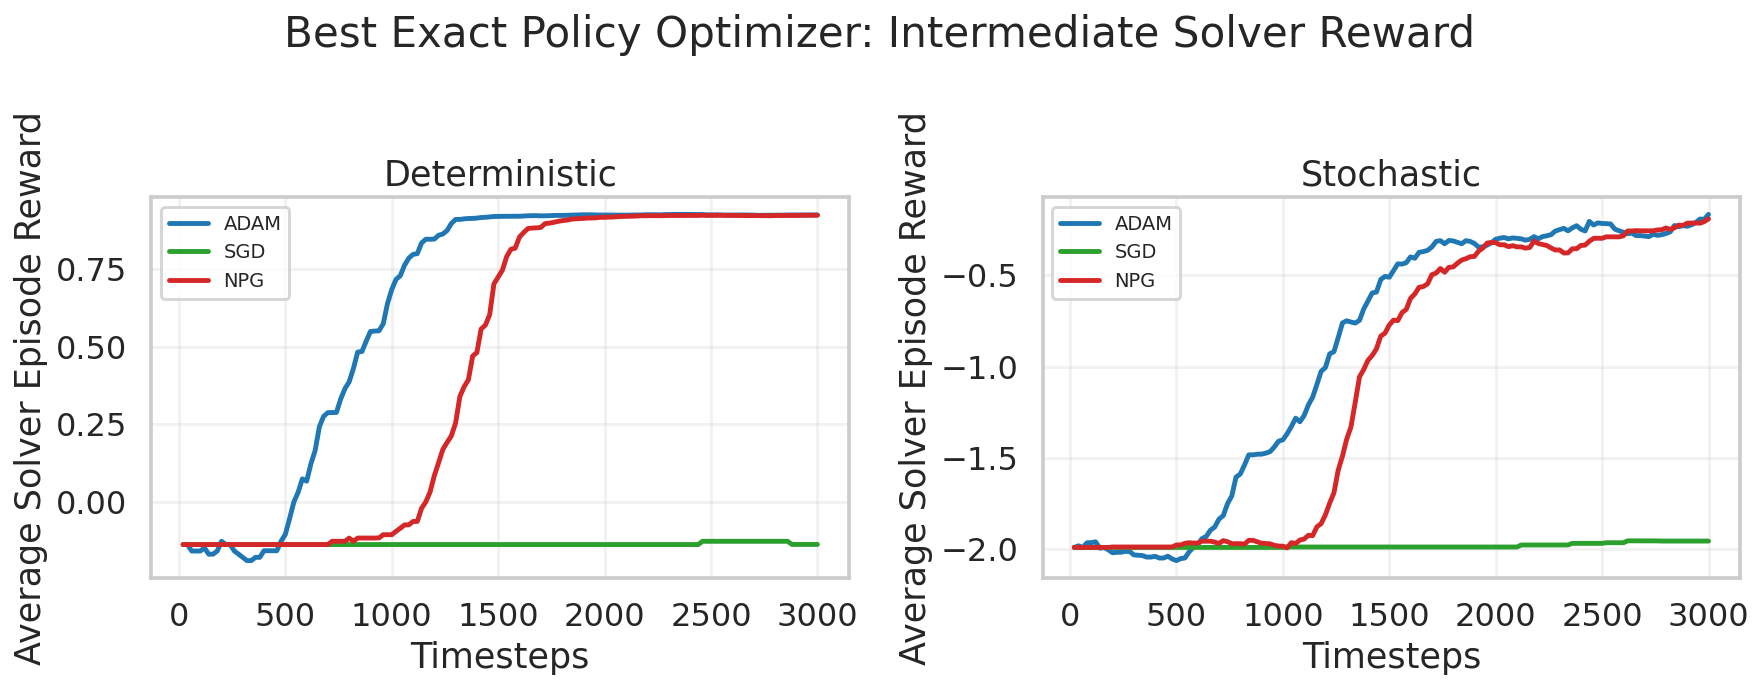

,problem,optimizer,ablation,alpha,fisher_damping,solver_avg_reward,solver_success_rate,greedy_avg_reward,greedy_success_rate
12,deterministic,ADAM,adam_exact_baseline,0.001,0.00100,0.92470,1.00,0.93000,1.00
31,deterministic,NPG,npg_exact_alpha_fisher,0.100,0.00100,0.92390,1.00,0.93000,1.00
92,deterministic,SGD,sgd_exact_alpha,0.030,0.00100,-0.13750,0.06,0.93000,1.00
133,stochastic,ADAM,adam_exact_baseline,0.001,0.00100,-0.16630,0.91,0.01875,0.93
144,stochastic,NPG,npg_exact_alpha_fisher,0.100,0.00003,-0.19075,0.89,0.01875,0.93
213,stochastic,SGD,sgd_exact_alpha,0.010,0.00100,-1.95515,0.06,0.01875,0.93


In [33]:
# Cell 1: policy optimizer comparison through learning curves
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()

ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"

POLICY_CSV = RESULTS_DIR / "final_linear_5grid_tabular_policy_ablation.csv"
POLICY_CURVE_STATS_CSV = RESULTS_DIR / "final_linear_5grid_tabular_policy_ablation_curve_stats.csv"

policy = pd.read_csv(POLICY_CSV)
policy = policy[policy["status"].eq("ok")].copy()

curves = pd.read_csv(POLICY_CURVE_STATS_CSV)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

# ============================================================
# Best exact update of each optimizer: Adam, SGD, NPG
# Plot intermediate solver avg reward
# ============================================================

exact = policy[policy["policy_gradient"].eq("exact")].copy()
exact["optimizer"] = exact["policy_optimizer"].str.upper()

best_exact = (
    exact.sort_values(
        ["problem", "optimizer", "solver_avg_reward", "solver_success_rate"],
        ascending=[True, True, False, False],
    )
    .groupby(["problem", "optimizer"], as_index=False)
    .head(1)
)

merge_cols = [
    "problem",
    "ablation",
    "policy_optimizer",
    "policy_gradient",
    "alpha",
    "reinforce_samples",
    "fisher_damping",
    "cg_iters",
    "cg_tol",
    "eta",
    "rho",
    "T",
    "theta_lambda",
    "theta_lr",
    "theta_inner_steps",
]

curve_best = curves.merge(
    best_exact[merge_cols + ["optimizer"]],
    on=merge_cols,
    how="inner",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)

optimizer_order = ["ADAM", "SGD", "NPG"]
optimizer_colors = {
    "ADAM": "#1f77b4",
    "SGD": "#2ca02c",
    "NPG": "#d62728",
}

for ax, problem in zip(axes, ["deterministic", "stochastic"]):
    sub_problem = curve_best[curve_best["problem"].eq(problem)].copy()

    for optimizer in optimizer_order:
        sub = sub_problem[sub_problem["optimizer"].eq(optimizer)].sort_values("checkpoint_step")
        if sub.empty:
            continue

        x = sub["checkpoint_step"].to_numpy()
        y = sub["solver_avg_reward_mean"].to_numpy()
        err = sub["solver_avg_reward_std"].fillna(0.0).to_numpy()

        ax.plot(
            x,
            y,
            linewidth=2.5,
            color=optimizer_colors[optimizer],
            label=optimizer,
        )
        ax.fill_between(
            x,
            y - err,
            y + err,
            color=optimizer_colors[optimizer],
            alpha=0.14,
        )

    ax.set_title(problem.capitalize())
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Average Solver Episode Reward")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, fontsize=10)

fig.suptitle("Best Exact Policy Optimizer: Intermediate Solver Reward", y=1.04)
fig.tight_layout()
plt.show()

display(
    best_exact[
        [
            "problem",
            "optimizer",
            "ablation",
            "alpha",
            "fisher_damping",
            "solver_avg_reward",
            "solver_success_rate",
            "greedy_avg_reward",
            "greedy_success_rate",
        ]
    ].sort_values(["problem", "optimizer"])
)

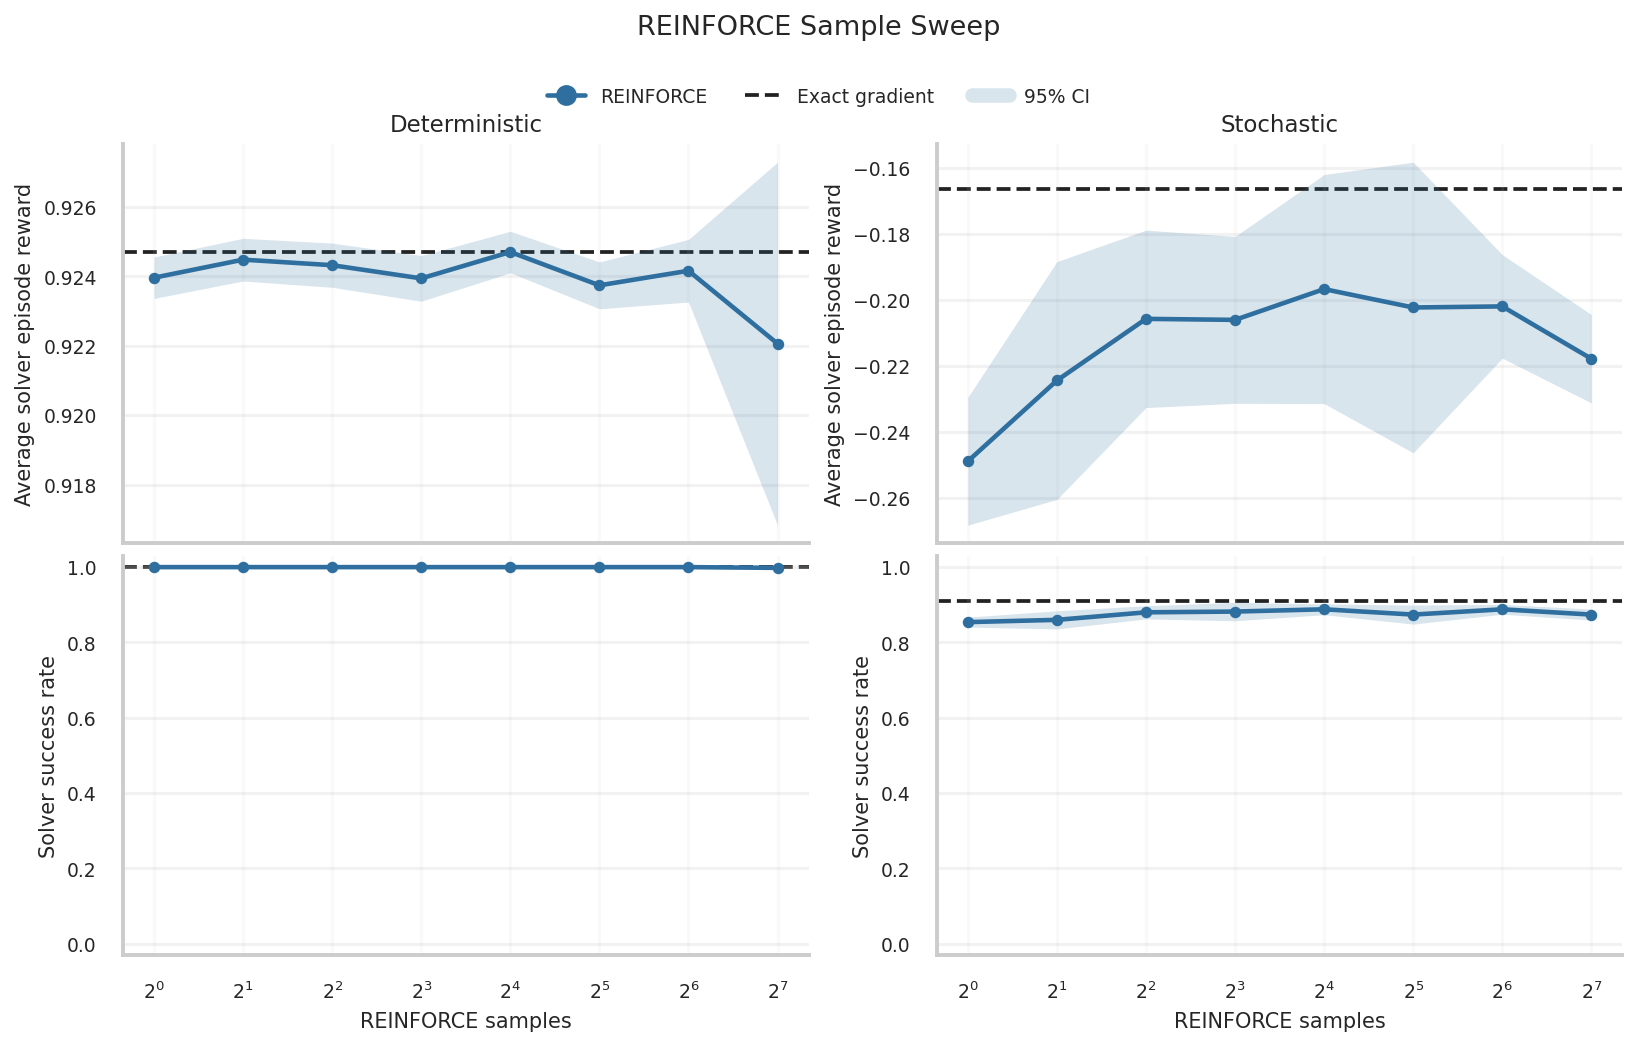

,problem,reinforce_samples,count,reward_mean,reward_std,success_mean,success_std,reward_sem,success_sem,reward_ci95,success_ci95,baseline_reward,baseline_success
0,deterministic,1,5,0.92396,0.000680,1.000,0.000000,0.000304,0.000000,0.000596,0.000000,0.9247,1.00
1,deterministic,2,5,0.92448,0.000701,1.000,0.000000,0.000314,0.000000,0.000615,0.000000,0.9247,1.00
2,deterministic,4,5,0.92432,0.000726,1.000,0.000000,0.000325,0.000000,0.000636,0.000000,0.9247,1.00
3,deterministic,8,5,0.92394,0.000750,1.000,0.000000,0.000336,0.000000,0.000658,0.000000,0.9247,1.00
4,deterministic,16,5,0.92470,0.000682,1.000,0.000000,0.000305,0.000000,0.000598,0.000000,0.9247,1.00
5,deterministic,32,5,0.92374,0.000770,1.000,0.000000,0.000344,0.000000,0.000675,0.000000,0.9247,1.00
6,deterministic,64,5,0.92416,0.001029,1.000,0.000000,0.000460,0.000000,0.000902,0.000000,0.9247,1.00
7,deterministic,128,5,0.92206,0.005965,0.998,0.004472,0.002668,0.002000,0.005229,0.003920,0.9247,1.00
8,stochastic,1,5,-0.24894,0.022119,0.854,0.015166,0.009892,0.006782,0.019388,0.013293,-0.1663,0.91
9,stochastic,2,5,-0.22443,0.041158,0.860,0.027386,0.018406,0.012247,0.036077,0.024005,-0.1663,0.91


In [42]:
# Cell 2: REINFORCE sample sweep: reward + success rate vs exact baseline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()


ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"

POLICY_CSV = RESULTS_DIR / "final_linear_5grid_tabular_policy_ablation.csv"

policy = pd.read_csv(POLICY_CSV)
policy = policy[policy["status"].eq("ok")].copy()

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Use "ci95" for paper-style uncertainty, or "std" for raw seed variability.
ERROR_MODE = "ci95"

reinforce = policy[
    policy["policy_optimizer"].eq("adam")
    & policy["policy_gradient"].eq("reinforce")
].copy()

reinforce_summary = (
    reinforce.groupby(["problem", "reinforce_samples"], as_index=False)
    .agg(
        count=("solver_avg_reward", "size"),
        reward_mean=("solver_avg_reward", "mean"),
        reward_std=("solver_avg_reward", "std"),
        success_mean=("solver_success_rate", "mean"),
        success_std=("solver_success_rate", "std"),
    )
)

reinforce_summary[["reward_std", "success_std"]] = reinforce_summary[
    ["reward_std", "success_std"]
].fillna(0.0)

reinforce_summary["reward_sem"] = (
    reinforce_summary["reward_std"] / np.sqrt(reinforce_summary["count"])
)
reinforce_summary["success_sem"] = (
    reinforce_summary["success_std"] / np.sqrt(reinforce_summary["count"])
)

reinforce_summary["reward_ci95"] = 1.96 * reinforce_summary["reward_sem"]
reinforce_summary["success_ci95"] = 1.96 * reinforce_summary["success_sem"]

baseline = policy[
    policy["ablation"].eq("adam_exact_baseline")
    & policy["policy_optimizer"].eq("adam")
    & policy["policy_gradient"].eq("exact")
].copy()

baseline = (
    baseline.groupby("problem", as_index=False)
    .agg(
        baseline_reward=("solver_avg_reward", "mean"),
        baseline_success=("solver_success_rate", "mean"),
    )
)

line_color = "#2f6f9f"
band_color = "#2f6f9f"
baseline_color = "#222222"

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10.8, 6.2),
    sharex="col",
    constrained_layout=True,
)

problems = ["deterministic", "stochastic"]
metric_rows = [
    ("reward", "Average solver episode reward"),
    ("success", "Solver success rate"),
]

for col, problem in enumerate(problems):
    sub = reinforce_summary[
        reinforce_summary["problem"].eq(problem)
    ].sort_values("reinforce_samples")

    base = baseline[baseline["problem"].eq(problem)]

    for row, (metric, ylabel) in enumerate(metric_rows):
        ax = axes[row, col]

        if sub.empty:
            ax.set_title(problem.capitalize() if row == 0 else "")
            ax.text(
                0.5,
                0.5,
                "No REINFORCE rows",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        x = sub["reinforce_samples"].to_numpy(dtype=float)
        y = sub[f"{metric}_mean"].to_numpy(dtype=float)

        if ERROR_MODE == "std":
            err = sub[f"{metric}_std"].to_numpy(dtype=float)
            band_label = "Mean ± std"
        else:
            err = sub[f"{metric}_ci95"].to_numpy(dtype=float)
            band_label = "95% CI"

        lower = y - err
        upper = y + err

        if metric == "success":
            lower = np.clip(lower, 0.0, 1.0)
            upper = np.clip(upper, 0.0, 1.0)

        ax.fill_between(
            x,
            lower,
            upper,
            color=band_color,
            alpha=0.18,
            linewidth=0,
            zorder=1,
        )

        ax.plot(
            x,
            y,
            marker="o",
            markersize=4.5,
            linewidth=2.2,
            color=line_color,
            zorder=2,
        )

        if not base.empty:
            baseline_value = (
                base["baseline_reward"].iloc[0]
                if metric == "reward"
                else base["baseline_success"].iloc[0]
            )

            ax.axhline(
                baseline_value,
                color=baseline_color,
                linestyle="--",
                linewidth=1.8,
                zorder=0,
            )

        ax.set_xscale("log", base=2)
        ax.grid(True, axis="y", alpha=0.25)
        ax.grid(True, axis="x", alpha=0.10)
        ax.set_ylabel(ylabel)

        if row == 0:
            ax.set_title(problem.capitalize())

        if row == 1:
            ax.set_xlabel("REINFORCE samples")

        if metric == "success":
            ax.set_ylim(-0.03, 1.03)

legend_handles = [
    Line2D(
        [0], [0],
        color=line_color,
        marker="o",
        linewidth=2.2,
        label="REINFORCE",
    ),
    Line2D(
        [0], [0],
        color=baseline_color,
        linestyle="--",
        linewidth=1.8,
        label="Exact gradient",
    ),
    Line2D(
        [0], [0],
        color=band_color,
        linewidth=7,
        alpha=0.18,
        label=band_label,
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,
    frameon=False,
)

fig.suptitle("REINFORCE Sample Sweep", y=1.10, fontsize=13)
plt.show()

display(
    reinforce_summary
    .merge(baseline, on="problem", how="left")
    .sort_values(["problem", "reinforce_samples"])
)

# Theta update

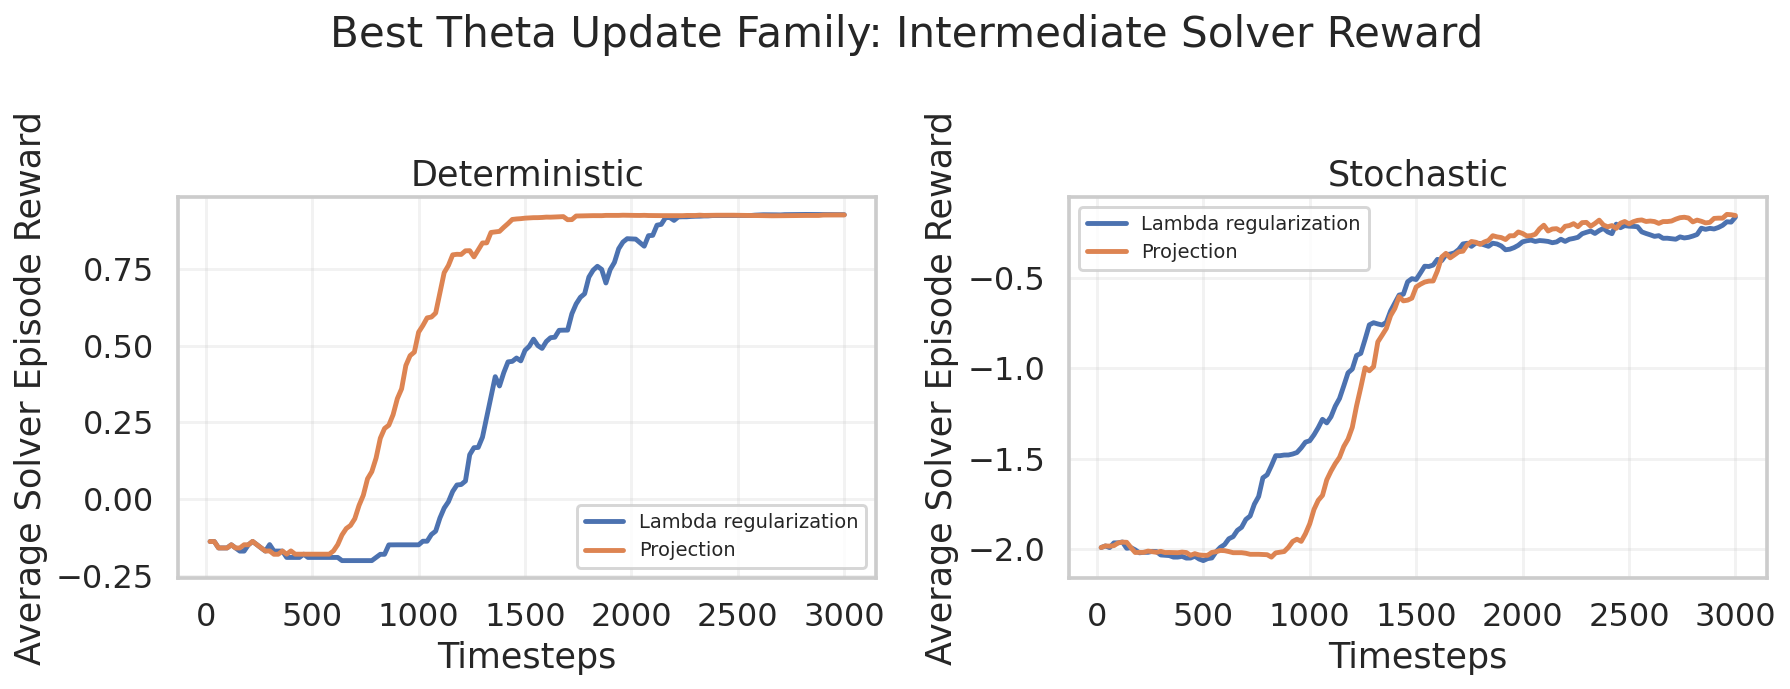

,problem,family,theta_start_mode,theta_lambda,D_theta,theta_inner_steps,solver_avg_reward,solver_success_rate,greedy_avg_reward,greedy_success_rate
0,deterministic,Lambda regularization,warm,3.000000e-07,NaN,10,0.92580,1.00,0.93000,1.00
5,deterministic,Projection,warm,NaN,300.0,10,0.92500,1.00,0.93000,1.00
91,stochastic,Lambda regularization,warm,3.000000e-07,NaN,10,-0.16630,0.91,0.01875,0.93
105,stochastic,Projection,warm,NaN,10.0,10,-0.15715,0.90,0.01875,0.93


In [40]:
# Cell 2: theta ablation plots
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()

ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"

THETA_CSV = RESULTS_DIR / "final_linear_5grid_tabular_theta_ablation.csv"
THETA_CURVE_STATS_CSV = RESULTS_DIR / "final_linear_5grid_tabular_theta_ablation_curve_stats.csv"

theta = pd.read_csv(THETA_CSV)
theta = theta[theta["status"].eq("ok")].copy()

curves = pd.read_csv(THETA_CURVE_STATS_CSV)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

# ============================================================
# 1. Lambda regularization vs projection:
#    take best final config, then plot intermediate solver reward
# ============================================================

compare = theta[theta["ablation"].isin(["reg_fixed_lambda", "projection_dtheta"])].copy()
compare["family"] = compare["ablation"].map({
    "reg_fixed_lambda": "Lambda regularization",
    "projection_dtheta": "Projection",
})

best_compare = (
    compare.sort_values(
        ["problem", "family", "solver_avg_reward", "solver_success_rate"],
        ascending=[True, True, False, False],
    )
    .groupby(["problem", "family"], as_index=False)
    .head(1)
)

merge_cols = [
    "problem",
    "ablation",
    "theta_mode",
    "theta_start_mode",
    "theta_lambda",
    "D_theta",
    "theta_lr",
    "theta_inner_steps",
    "rho",
    "T",
]

curve_best = curves.merge(
    best_compare[merge_cols + ["family"]],
    on=merge_cols,
    how="inner",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=False)

for ax, problem in zip(axes, ["deterministic", "stochastic"]):
    sub_problem = curve_best[curve_best["problem"].eq(problem)].copy()

    for family in ["Lambda regularization", "Projection"]:
        sub = sub_problem[sub_problem["family"].eq(family)].sort_values("checkpoint_step")
        if sub.empty:
            continue

        x = sub["checkpoint_step"].to_numpy()
        y = sub["solver_avg_reward_mean"].to_numpy()
        err = sub["solver_avg_reward_std"].fillna(0.0).to_numpy()

        ax.plot(x, y, linewidth=2.5, label=family)
        ax.fill_between(x, y - err, y + err, alpha=0.16)

    ax.set_title(problem.capitalize())
    ax.set_xlabel("Timesteps")
    ax.set_ylabel("Average Solver Episode Reward")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True, fontsize=10)

fig.suptitle("Best Theta Update Family: Intermediate Solver Reward", y=1.04)
fig.tight_layout()
plt.show()

display(
    best_compare[
        [
            "problem",
            "family",
            "theta_start_mode",
            "theta_lambda",
            "D_theta",
            "theta_inner_steps",
            "solver_avg_reward",
            "solver_success_rate",
            "greedy_avg_reward",
            "greedy_success_rate",
        ]
    ].sort_values(["problem", "family"])
)

lambda max reward std: 0.0
inner max reward std: 0.0


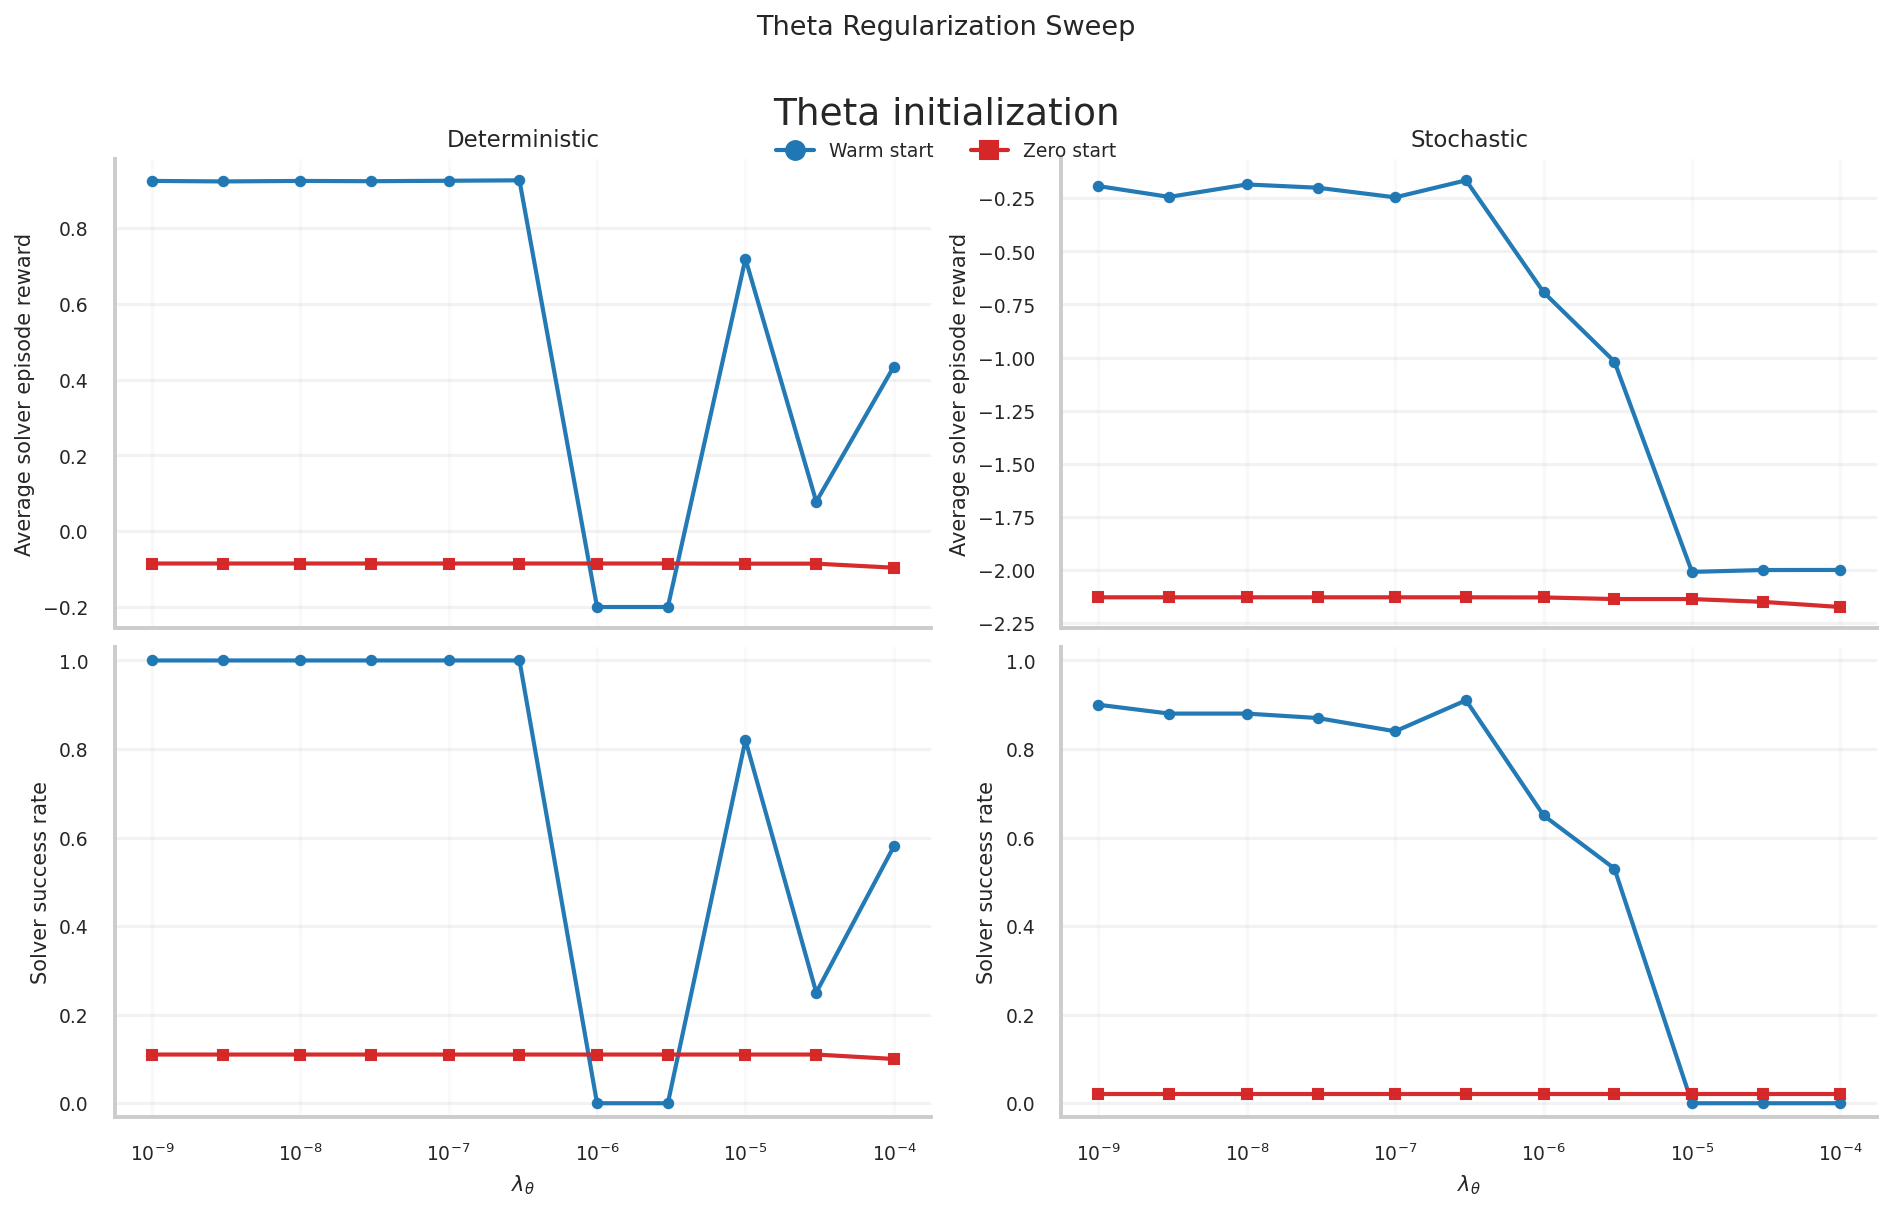

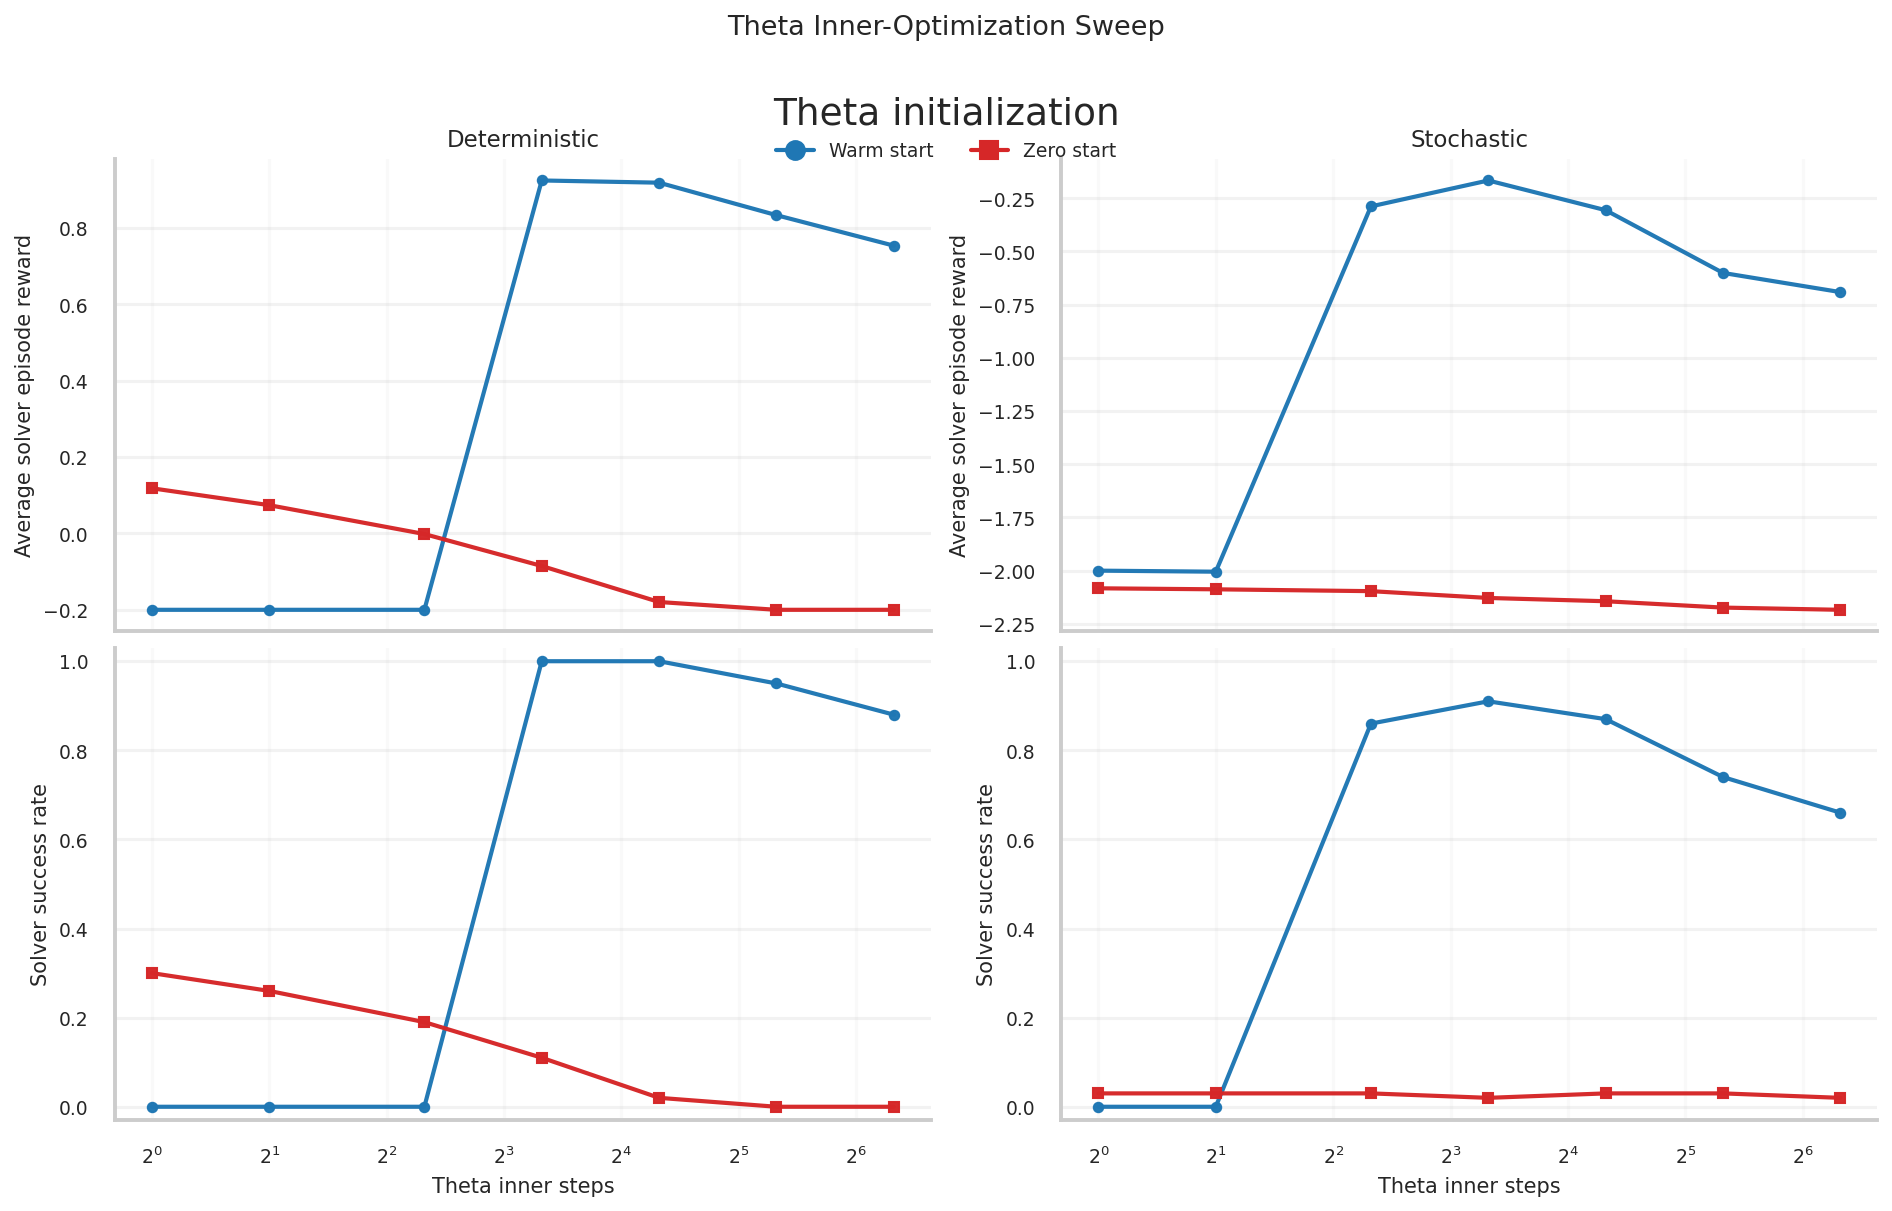

In [39]:
# Paper-style theta sweep plots with correctly grouped seed std bands
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()


ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"

THETA_CURVES_CSV = RESULTS_DIR / "final_linear_5grid_tabular_theta_ablation_curves.csv"
raw = pd.read_csv(THETA_CURVES_CSV)

# Use final checkpoint only.
raw = raw[raw["checkpoint_step"].eq(raw["checkpoint_step"].max())].copy()

group_cols = [
    "problem",
    "ablation",
    "theta_mode",
    "theta_start_mode",
    "theta_lambda",
    "D_theta",
    "theta_lr",
    "theta_inner_steps",
    "rho",
    "T",
    "checkpoint_step",
]

curves = (
    raw.groupby(group_cols, dropna=False, as_index=False)
    .agg(
        seed_count=("seed", "nunique"),
        solver_avg_reward_mean=("solver_avg_reward", "mean"),
        solver_avg_reward_std=("solver_avg_reward", "std"),
        solver_success_rate_mean=("solver_success_rate", "mean"),
        solver_success_rate_std=("solver_success_rate", "std"),
    )
)

curves[[
    "solver_avg_reward_std",
    "solver_success_rate_std",
]] = curves[[
    "solver_avg_reward_std",
    "solver_success_rate_std",
]].fillna(0.0)

print("lambda max reward std:",
      curves[curves["ablation"].eq("reg_fixed_lambda")]["solver_avg_reward_std"].max())
print("inner max reward std:",
      curves[curves["ablation"].eq("reg_fixed_inner_steps")]["solver_avg_reward_std"].max())

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

start_colors = {
    "warm": "#1f77b4",
    "zero": "#d62728",
}

start_labels = {
    "warm": "Warm start",
    "zero": "Zero start",
}

start_markers = {
    "warm": "o",
    "zero": "s",
}


def plot_theta_sweep(df, sweep_col, title, xlabel, xscale="log", base=None):
    fig, axes = plt.subplots(
        2, 2,
        figsize=(12.5, 7.2),
        sharex="col",
        constrained_layout=True,
    )

    metric_rows = [
        ("solver_avg_reward", "Average solver episode reward"),
        ("solver_success_rate", "Solver success rate"),
    ]

    problems = ["deterministic", "stochastic"]

    for col, problem in enumerate(problems):
        for row, (metric, ylabel) in enumerate(metric_rows):
            ax = axes[row, col]

            for start in ["warm", "zero"]:
                sub = df[
                    df["problem"].eq(problem)
                    & df["theta_start_mode"].eq(start)
                ].sort_values(sweep_col)

                if sub.empty:
                    continue

                x = sub[sweep_col].to_numpy(dtype=float)
                y = sub[f"{metric}_mean"].to_numpy(dtype=float)
                std = sub[f"{metric}_std"].fillna(0.0).to_numpy(dtype=float)

                lower = y - std
                upper = y + std

                if metric == "solver_success_rate":
                    lower = np.clip(lower, 0.0, 1.0)
                    upper = np.clip(upper, 0.0, 1.0)

                ax.fill_between(
                    x,
                    lower,
                    upper,
                    color=start_colors[start],
                    alpha=0.25,
                    linewidth=0,
                    zorder=1,
                )

                ax.plot(
                    x,
                    y,
                    color=start_colors[start],
                    marker=start_markers[start],
                    markersize=4.5,
                    linewidth=2.0,
                    alpha=0.98,
                    label=start_labels[start],
                    zorder=2,
                )

            if xscale == "log" and base is not None:
                ax.set_xscale("log", base=base)
            elif xscale:
                ax.set_xscale(xscale)

            ax.grid(True, axis="y", alpha=0.25)
            ax.grid(True, axis="x", alpha=0.10)
            ax.set_ylabel(ylabel)

            if row == 0:
                ax.set_title(problem.capitalize())

            if row == 1:
                ax.set_xlabel(xlabel)

            if metric == "solver_success_rate":
                ax.set_ylim(-0.03, 1.03)

    handles = [
        Line2D(
            [0], [0],
            color=start_colors[start],
            marker=start_markers[start],
            linewidth=2.0,
            label=start_labels[start],
        )
        for start in ["warm", "zero"]
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        frameon=False,
        title="Theta initialization",
    )

    fig.suptitle(title, y=1.10, fontsize=13)
    plt.show()


lambda_sweep = curves[curves["ablation"].eq("reg_fixed_lambda")].copy()
inner_sweep = curves[curves["ablation"].eq("reg_fixed_inner_steps")].copy()

plot_theta_sweep(
    lambda_sweep,
    sweep_col="theta_lambda",
    title="Theta Regularization Sweep",
    xlabel=r"$\lambda_\theta$",
    xscale="log",
)

plot_theta_sweep(
    inner_sweep,
    sweep_col="theta_inner_steps",
    title="Theta Inner-Optimization Sweep",
    xlabel="Theta inner steps",
    xscale="log",
    base=2,
)